### Final Results Hamburg

In [1]:
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()

DB_CONFIG = {
    'host': 'localhost',
    'dbname': os.getenv("POSTGRES_DB"),
    'user': os.getenv("POSTGRES_USER"),
    'password': os.getenv("POSTGRES_PASSWORD"),
    'port': 5432
}


engine = create_engine(f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}@"
                f"{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}")


In [2]:
import pandas as pd
import geopandas as gpd
query = "SELECT * FROM grid_validation_hamburg"

counts_comp_gdf = gpd.GeoDataFrame.from_postgis(query,engine, geom_col="geom")
counts_comp_gdf

,geom,id,counter_id,count_db,count_sr,count_base,count_sim,count_base_pois,count_base_nrd,count_base_dist
0,"POLYGON ((9.88147 53.47849, 9.88147 53.48383, ...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"POLYGON ((9.88147 53.48383, 9.88147 53.48918, ...",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"POLYGON ((9.88147 53.48918, 9.88147 53.49452, ...",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"POLYGON ((9.88147 53.49452, 9.88147 53.49986, ...",4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"POLYGON ((9.88147 53.49986, 9.88147 53.50521, ...",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
645,"POLYGON ((9.93537 53.54259, 9.93537 53.54793, ...",163,18065.0,5672.0,896.0,1322.0,923.0,1705.0,3387.0,551.0
646,"POLYGON ((9.93537 53.57461, 9.93537 53.57994, ...",169,19423.0,9952.0,356.0,2019.0,1104.0,1126.0,2633.0,480.0
647,"POLYGON ((9.93537 53.59061, 9.93537 53.59594, ...",172,9111.0,1212.0,NaN,NaN,NaN,NaN,NaN,NaN
648,"POLYGON ((10.08808 53.5586, 10.08808 53.56394,...",591,4902.0,848.0,56.0,27.0,84.0,45.0,88.0,40.0


In [3]:
counts_comp_gdf = counts_comp_gdf.dropna()
counts_comp_gdf["rank_db"] = counts_comp_gdf["count_db"].rank(ascending=False)
counts_comp_gdf["rank_base"] = counts_comp_gdf["count_base"].rank(ascending=False)
counts_comp_gdf["rank_base_pois"] = counts_comp_gdf["count_base_pois"].rank(ascending=False)
counts_comp_gdf["rank_base_nrd"] = counts_comp_gdf["count_base_nrd"].rank(ascending=False)
counts_comp_gdf["rank_base_dist"] = counts_comp_gdf["count_base_dist"].rank(ascending=False)

counts_comp_gdf["rank_sim"] = counts_comp_gdf["count_sim"].rank(ascending=False)
counts_comp_gdf["rank_sr"] = counts_comp_gdf["count_sr"].rank(ascending=False)
counts_comp_gdf["rank_diff"] = counts_comp_gdf["rank_db"] - counts_comp_gdf["rank_sim"]

counts_comp_df = pd.DataFrame(counts_comp_gdf[["id","count_db","count_base","count_sim","count_sr","count_base_pois","count_base_nrd","count_base_dist","rank_base","rank_db","rank_sr", "rank_base_pois","rank_base_nrd","rank_base_dist",
                                               "rank_sim","rank_diff" ]])
counts_comp_df

,id,count_db,count_base,count_sim,count_sr,count_base_pois,count_base_nrd,count_base_dist,rank_base,rank_db,rank_sr,rank_base_pois,rank_base_nrd,rank_base_dist,rank_sim,rank_diff
205,458,160.0,194.0,226.0,144.0,206.0,523.0,82.0,246.0,303.0,268.0,236.0,221.0,233.5,230.0,73.0
222,440,16904.0,7536.0,3766.0,2808.0,6520.0,12840.0,1966.0,27.0,44.0,32.5,8.0,10.0,24.0,23.0,21.0
233,469,5448.0,3704.0,1916.0,680.0,2945.0,5968.0,1056.0,70.0,187.0,186.0,64.0,63.0,70.0,78.0,109.0
234,408,316.0,193.0,11.0,68.0,26.0,22.0,4.0,248.0,297.0,283.5,284.5,292.5,296.5,298.5,-1.5
235,559,740.0,142.0,105.0,92.0,73.0,126.0,16.0,264.0,288.0,279.0,263.0,269.0,282.0,255.0,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,192,15040.0,4299.0,2960.0,1712.0,3486.0,7127.0,1581.0,61.5,61.0,95.0,49.5,47.0,36.5,37.5,23.5
645,163,5672.0,1322.0,923.0,896.0,1705.0,3387.0,551.0,153.5,182.5,167.0,104.0,103.0,144.0,157.0,25.5
646,169,9952.0,2019.0,1104.0,356.0,1126.0,2633.0,480.0,113.5,125.5,223.5,148.5,143.5,154.5,146.5,-21.0
648,591,848.0,27.0,84.0,56.0,45.0,88.0,40.0,292.0,283.0,285.5,271.0,272.0,260.5,263.0,20.0


In [4]:
counts_comp_df[["count_db","count_sr","count_base",
                "count_base_pois","count_base_nrd","count_base_dist",
                "count_sim",]].corr()

,count_db,count_sr,count_base,count_base_pois,count_base_nrd,count_base_dist,count_sim
count_db,1.000000,0.890563,0.572918,0.687532,0.693205,0.720483,0.727776
count_sr,0.890563,1.000000,0.623138,0.724848,0.734449,0.760753,0.761986
count_base,0.572918,0.623138,1.000000,0.906054,0.908704,0.820959,0.815874
count_base_pois,0.687532,0.724848,0.906054,1.000000,0.995743,0.953829,0.948149
count_base_nrd,0.693205,0.734449,0.908704,0.995743,1.000000,0.955332,0.950034
count_base_dist,0.720483,0.760753,0.820959,0.953829,0.955332,1.000000,0.994671
count_sim,0.727776,0.761986,0.815874,0.948149,0.950034,0.994671,1.000000


In [5]:
counts_comp_df[["rank_db","rank_sr","rank_base",
                "rank_base_pois","rank_base_nrd","rank_base_dist",
                "rank_sim",]].corr()

,rank_db,rank_sr,rank_base,rank_base_pois,rank_base_nrd,rank_base_dist,rank_sim
rank_db,1.000000,0.882281,0.526355,0.620333,0.626130,0.663635,0.672747
rank_sr,0.882281,1.000000,0.585063,0.683925,0.689169,0.718847,0.721449
rank_base,0.526355,0.585063,1.000000,0.937442,0.936003,0.867654,0.863594
rank_base_pois,0.620333,0.683925,0.937442,1.000000,0.994709,0.963695,0.957750
rank_base_nrd,0.626130,0.689169,0.936003,0.994709,1.000000,0.966804,0.961063
rank_base_dist,0.663635,0.718847,0.867654,0.963695,0.966804,1.000000,0.993243
rank_sim,0.672747,0.721449,0.863594,0.957750,0.961063,0.993243,1.000000


In [6]:
counts_comp_df[["rank_db","rank_sr","rank_base",
                "rank_base_pois","rank_base_nrd","rank_base_dist",
                "rank_sim",]].corr(method="kendall")

,rank_db,rank_sr,rank_base,rank_base_pois,rank_base_nrd,rank_base_dist,rank_sim
rank_db,1.000000,0.708741,0.372304,0.443750,0.448629,0.478615,0.488414
rank_sr,0.708741,1.000000,0.419636,0.507058,0.512638,0.540376,0.542952
rank_base,0.372304,0.419636,1.000000,0.795203,0.786597,0.689239,0.681844
rank_base_pois,0.443750,0.507058,0.795203,1.000000,0.944253,0.842306,0.828071
rank_base_nrd,0.448629,0.512638,0.786597,0.944253,1.000000,0.850844,0.835949
rank_base_dist,0.478615,0.540376,0.689239,0.842306,0.850844,1.000000,0.934762
rank_sim,0.488414,0.542952,0.681844,0.828071,0.835949,0.934762,1.000000


In [57]:
from scipy.stats import spearmanr

list_sim = []
list_base = []
list_base_pois = []
list_base_nrd = []
list_base_dist = []
list_sr = []

for i in range(10,len(counts_comp_df) + 5, 10):
    counts_comp_df_red = counts_comp_df[counts_comp_df["rank_db"] < i]
    counts_comp_df_red["rank_base"] = counts_comp_df_red["count_base"].rank(ascending=False)
    counts_comp_df_red["rank_base_pois"] = counts_comp_df_red["count_base_pois"].rank(ascending=False)
    counts_comp_df_red["rank_base_nrd"] = counts_comp_df_red["count_base_nrd"].rank(ascending=False)
    counts_comp_df_red["rank_base_dist"] = counts_comp_df_red["count_base_dist"].rank(ascending=False)
    counts_comp_df_red["rank_sim"] = counts_comp_df_red["count_sim"].rank(ascending=False)
    counts_comp_df_red["rank_sr"] = counts_comp_df_red["count_sr"].rank(ascending=False)
    res_sim = spearmanr(counts_comp_df_red["rank_db"], counts_comp_df_red["rank_sim"])
    res_base = spearmanr(counts_comp_df_red["rank_db"], counts_comp_df_red["rank_base"])
    res_base_pois = spearmanr(counts_comp_df_red["rank_db"], counts_comp_df_red["rank_base_pois"])
    res_base_nrd = spearmanr(counts_comp_df_red["rank_db"], counts_comp_df_red["rank_base_nrd"])
    res_base_dist = spearmanr(counts_comp_df_red["rank_db"], counts_comp_df_red["rank_base_dist"])
    res_sr = spearmanr(counts_comp_df_red["rank_db"], counts_comp_df_red["rank_sr"])
    list_base.append(res_base.statistic)
    list_base_pois.append(res_base_pois.statistic)
    list_base_nrd.append(res_base_nrd.statistic)
    list_base_dist.append(res_base_dist.statistic)
    list_sim.append(res_sim.statistic)
    list_sr.append(res_sr.statistic)

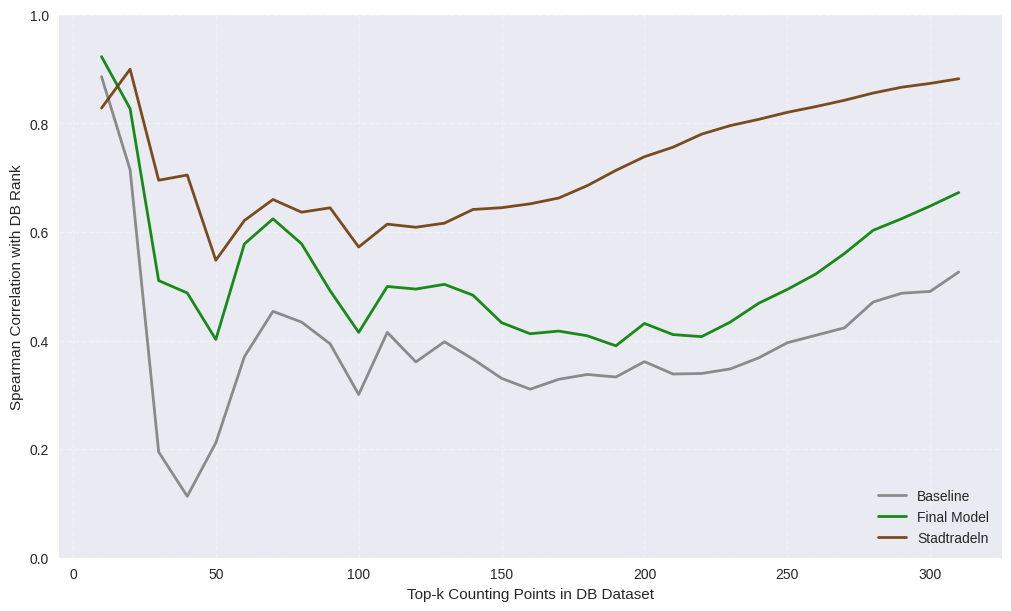

In [58]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

x=range(10,len(counts_comp_df) + 5, 10)
#plt.title("Spearman Correlation with Top-K Counting Points of DB Dataset")
plt.xlabel("Top-k Counting Points in DB Dataset")
plt.ylabel("Spearman Correlation with DB Rank")
plt.ylim(0, 1)

plt.style.use('seaborn-v0_8')
plt.grid(True, linestyle='--', alpha=0.3)

plt.plot(x, list_base, label="Baseline", linewidth =2, alpha=0.9, color="gray")
plt.plot(x, list_sim, label="Final Model",linewidth =2, alpha=0.9, color="green")
plt.plot(x, list_sr, label ="Stadtradeln",linewidth =2,alpha=0.9, color="#6D3B07")
plt.legend()

import tikzplotlib

tikzplotlib.save("figures/db_spearman_corr.tex")

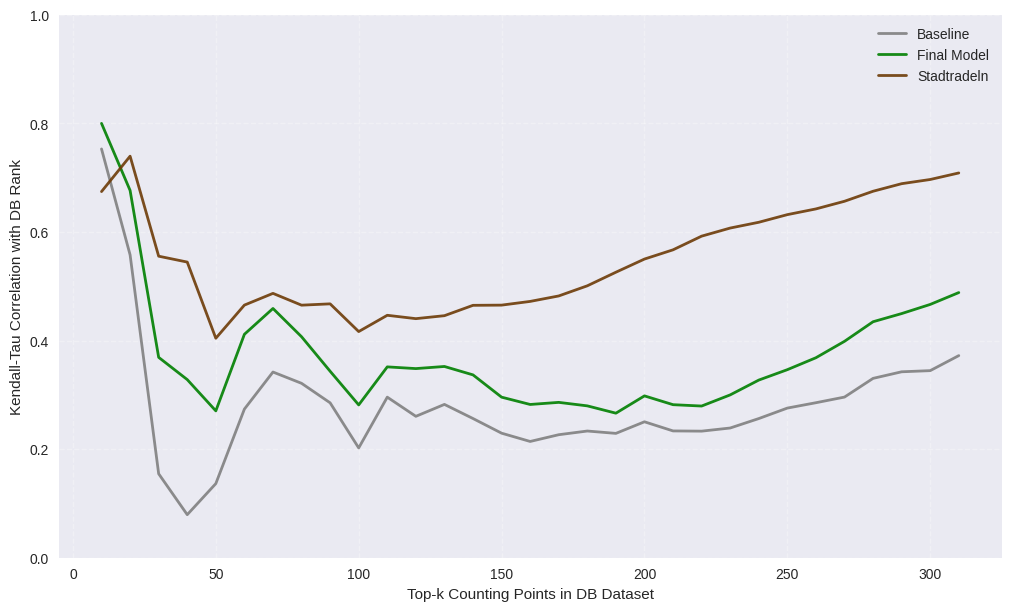

In [59]:
from scipy.stats import kendalltau

list_sim = []
list_base = []
list_base_pois = []
list_base_nrd = []
list_base_dist = []
list_sr = []

for i in range(10,len(counts_comp_df) + 5, 10):
    counts_comp_df_red = counts_comp_df[counts_comp_df["rank_db"] < i]
    counts_comp_df_red["rank_base"] = counts_comp_df_red["count_base"].rank(ascending=False)
    counts_comp_df_red["rank_base_pois"] = counts_comp_df_red["count_base_pois"].rank(ascending=False)
    counts_comp_df_red["rank_base_nrd"] = counts_comp_df_red["count_base_nrd"].rank(ascending=False)
    counts_comp_df_red["rank_base_dist"] = counts_comp_df_red["count_base_dist"].rank(ascending=False)
    counts_comp_df_red["rank_sim"] = counts_comp_df_red["count_sim"].rank(ascending=False)
    counts_comp_df_red["rank_sr"] = counts_comp_df_red["count_sr"].rank(ascending=False)
    res_sim = kendalltau(counts_comp_df_red["rank_db"], counts_comp_df_red["rank_sim"])
    res_base = kendalltau(counts_comp_df_red["rank_db"], counts_comp_df_red["rank_base"])
    res_base_pois = kendalltau(counts_comp_df_red["rank_db"], counts_comp_df_red["rank_base_pois"])
    res_base_nrd = kendalltau(counts_comp_df_red["rank_db"], counts_comp_df_red["rank_base_nrd"])
    res_base_dist = kendalltau(counts_comp_df_red["rank_db"], counts_comp_df_red["rank_base_dist"])
    res_sr = kendalltau(counts_comp_df_red["rank_db"], counts_comp_df_red["rank_sr"])
    list_base.append(res_base.statistic)
    list_base_pois.append(res_base_pois.statistic)
    list_base_nrd.append(res_base_nrd.statistic)
    list_base_dist.append(res_base_dist.statistic)
    list_sim.append(res_sim.statistic)
    list_sr.append(res_sr.statistic)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

x=range(10,len(counts_comp_df) + 5, 10)
#plt.title("Kendall-Tau Correlation with Top-K Counting Points of DB Dataset")
plt.xlabel("Top-k Counting Points in DB Dataset")
plt.ylabel("Kendall-Tau Correlation with DB Rank")
plt.ylim(0, 1)

plt.style.use('seaborn-v0_8')
plt.grid(True, linestyle='--', alpha=0.3)

plt.plot(x, list_base, label="Baseline", linewidth =2, alpha=0.9, color="gray")
plt.plot(x, list_sim, label="Final Model",linewidth =2, alpha=0.9, color="green")
plt.plot(x, list_sr, label ="Stadtradeln",linewidth =2,alpha=0.9, color="#6D3B07")
plt.legend()
plt.savefig("figures/db_kendalltau_corr")


import tikzplotlib

tikzplotlib.save("figures/db_kendalltau_corr.tex")

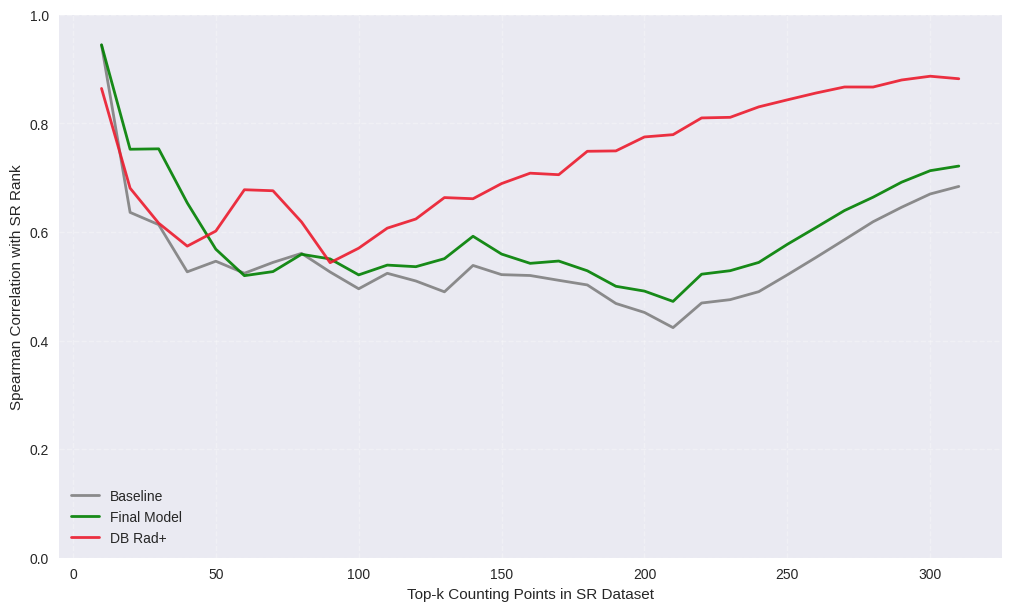

In [60]:
from scipy.stats import spearmanr

list_sim = []
list_base = []
list_base_pois = []
list_base_nrd = []
list_base_dist = []
list_sr = []

for i in range(10,len(counts_comp_df) + 5, 10):
    counts_comp_df_red = counts_comp_df[counts_comp_df["rank_sr"] < i]
    counts_comp_df_red["rank_base"] = counts_comp_df_red["count_base"].rank(ascending=False)
    counts_comp_df_red["rank_base_pois"] = counts_comp_df_red["count_base_pois"].rank(ascending=False)
    counts_comp_df_red["rank_base_nrd"] = counts_comp_df_red["count_base_nrd"].rank(ascending=False)
    counts_comp_df_red["rank_base_dist"] = counts_comp_df_red["count_base_dist"].rank(ascending=False)
    counts_comp_df_red["rank_sim"] = counts_comp_df_red["count_sim"].rank(ascending=False)
    counts_comp_df_red["rank_sr"] = counts_comp_df_red["count_sr"].rank(ascending=False)
    res_sim = spearmanr(counts_comp_df_red["rank_sr"], counts_comp_df_red["rank_sim"])
    res_base = spearmanr(counts_comp_df_red["rank_sr"], counts_comp_df_red["rank_base_pois"])
    res_base_pois = spearmanr(counts_comp_df_red["rank_sr"], counts_comp_df_red["rank_base_nrd"])
    res_base_nrd = spearmanr(counts_comp_df_red["rank_sr"], counts_comp_df_red["rank_base"])
    res_base_dist = spearmanr(counts_comp_df_red["rank_sr"], counts_comp_df_red["rank_base_dist"])
    res_sr = spearmanr(counts_comp_df_red["rank_db"], counts_comp_df_red["rank_sr"])
    list_base.append(res_base.statistic)
    list_base_pois.append(res_base_pois.statistic)
    list_base_nrd.append(res_base_nrd.statistic)
    list_base_dist.append(res_base_dist.statistic)
    list_sim.append(res_sim.statistic)
    list_sr.append(res_sr.statistic)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

x=range(10,len(counts_comp_df) + 5, 10)
#plt.title("Spearman Correlation with Top-K Counting Points of SR Dataset")
plt.xlabel("Top-k Counting Points in SR Dataset")
plt.ylabel("Spearman Correlation with SR Rank")
plt.ylim(0, 1)

plt.style.use('seaborn-v0_8')
plt.grid(True, linestyle='--', alpha=0.3)

plt.plot(x, list_base, label="Baseline", linewidth =2, alpha=0.9, color="gray")
plt.plot(x, list_sim, label="Final Model",linewidth =2, alpha=0.9, color="green")
plt.plot(x, list_sr, label ="DB Rad+",linewidth =2,alpha=0.9, color="#EC1B2D")
plt.legend()
plt.savefig("figures/sr_spearman_corr")

import tikzplotlib

tikzplotlib.save("figures/sr_spearman_corr.tex")

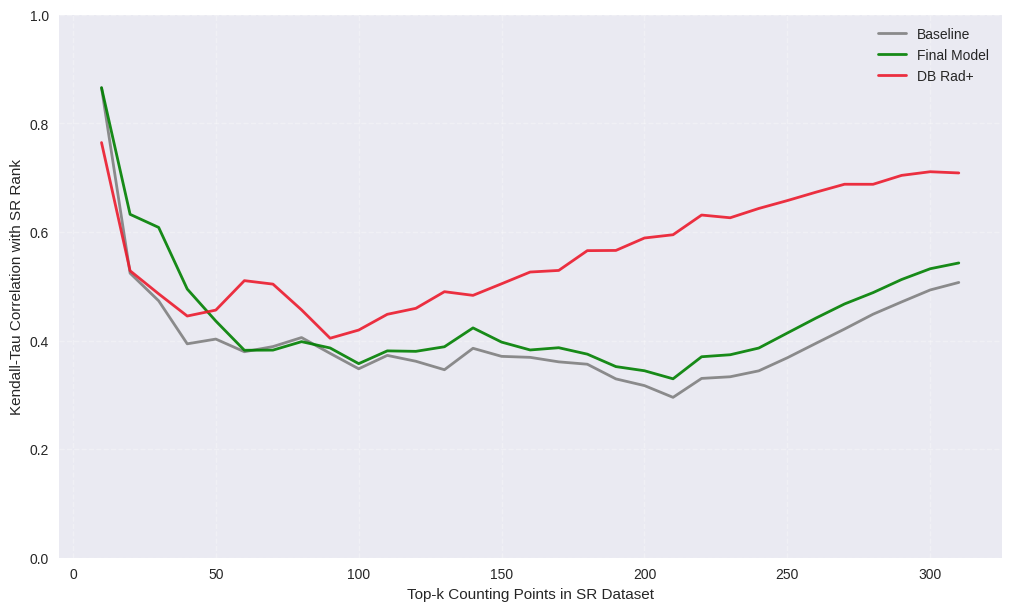

In [61]:
from scipy.stats import kendalltau

list_sim = []
list_base = []
list_base_pois = []
list_base_nrd = []
list_base_dist = []
list_sr = []

for i in range(10,len(counts_comp_df) + 5, 10):
    counts_comp_df_red = counts_comp_df[counts_comp_df["rank_sr"] < i]
    counts_comp_df_red["rank_base"] = counts_comp_df_red["count_base"].rank(ascending=False)
    counts_comp_df_red["rank_base_pois"] = counts_comp_df_red["count_base_pois"].rank(ascending=False)
    counts_comp_df_red["rank_base_nrd"] = counts_comp_df_red["count_base_nrd"].rank(ascending=False)
    counts_comp_df_red["rank_base_dist"] = counts_comp_df_red["count_base_dist"].rank(ascending=False)
    counts_comp_df_red["rank_sim"] = counts_comp_df_red["count_sim"].rank(ascending=False)
    counts_comp_df_red["rank_sr"] = counts_comp_df_red["count_sr"].rank(ascending=False)
    res_sim = kendalltau(counts_comp_df_red["rank_sr"], counts_comp_df_red["rank_sim"])
    res_base = kendalltau(counts_comp_df_red["rank_sr"], counts_comp_df_red["rank_base_pois"])
    res_base_pois = kendalltau(counts_comp_df_red["rank_sr"], counts_comp_df_red["rank_base_nrd"])
    res_base_nrd = kendalltau(counts_comp_df_red["rank_sr"], counts_comp_df_red["rank_base"])
    res_base_dist = kendalltau(counts_comp_df_red["rank_sr"], counts_comp_df_red["rank_base_dist"])
    res_sr = kendalltau(counts_comp_df_red["rank_db"], counts_comp_df_red["rank_sr"])
    list_base.append(res_base.statistic)
    list_base_pois.append(res_base_pois.statistic)
    list_base_nrd.append(res_base_nrd.statistic)
    list_base_dist.append(res_base_dist.statistic)
    list_sim.append(res_sim.statistic)
    list_sr.append(res_sr.statistic)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

x=range(10,len(counts_comp_df) + 5, 10)
#plt.title("Kendall-Tau Correlation with Top-K Counting Points of SR Dataset")
plt.xlabel("Top-k Counting Points in SR Dataset")
plt.ylabel("Kendall-Tau Correlation with SR Rank")
plt.ylim(0, 1)

plt.style.use('seaborn-v0_8')
plt.grid(True, linestyle='--', alpha=0.3)

plt.plot(x, list_base, label="Baseline", linewidth =2, alpha=0.9, color="gray")
plt.plot(x, list_sim, label="Final Model",linewidth =2, alpha=0.9, color="green")
plt.plot(x, list_sr, label ="DB Rad+",linewidth =2,alpha=0.9, color="#EC1B2D")
plt.legend()
plt.savefig("figures/sr_kendalltau_corr")

import tikzplotlib

tikzplotlib.save("figures/sr_kendalltau_corr.tex")

In [62]:
from scipy.stats import pearsonr

list_sim = []
list_base = []
list_base_pois = []
list_base_nrd = []
list_base_dist = []
list_sr = []

for i in range(10,len(counts_comp_df) + 5, 10):
    counts_comp_df_red = counts_comp_df[counts_comp_df["rank_db"] < i]
    counts_comp_df_red["rank_base"] = counts_comp_df_red["count_base"].rank(ascending=False)
    counts_comp_df_red["rank_base_pois"] = counts_comp_df_red["count_base_pois"].rank(ascending=False)
    counts_comp_df_red["rank_base_nrd"] = counts_comp_df_red["count_base_nrd"].rank(ascending=False)
    counts_comp_df_red["rank_base_dist"] = counts_comp_df_red["count_base_dist"].rank(ascending=False)
    counts_comp_df_red["rank_sim"] = counts_comp_df_red["count_sim"].rank(ascending=False)
    counts_comp_df_red["rank_sr"] = counts_comp_df_red["count_sr"].rank(ascending=False)
    res_sim = pearsonr(counts_comp_df_red["count_db"], counts_comp_df_red["count_sim"])
    res_base = pearsonr(counts_comp_df_red["count_db"], counts_comp_df_red["count_base_pois"])
    res_sr = pearsonr(counts_comp_df_red["count_db"], counts_comp_df_red["count_sr"])
    list_base.append(res_base.statistic)
    list_base_pois.append(res_base_pois.statistic)
    list_base_nrd.append(res_base_nrd.statistic)
    list_base_dist.append(res_base_dist.statistic)
    list_sim.append(res_sim.statistic)
    list_sr.append(res_sr.statistic)

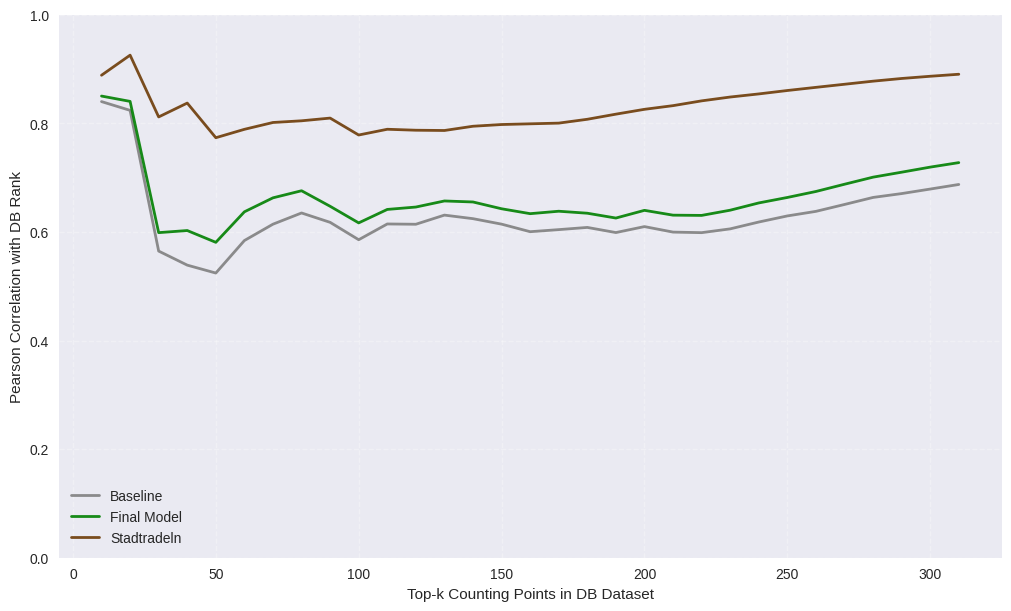

In [63]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

x=range(10,len(counts_comp_df) + 5, 10)
#plt.title("Pearson Correlation with Top-K Counting Points of DB Dataset")
plt.xlabel("Top-k Counting Points in DB Dataset")
plt.ylabel("Pearson Correlation with DB Rank")
plt.ylim(0, 1)

plt.style.use('seaborn-v0_8')
plt.grid(True, linestyle='--', alpha=0.3)

plt.plot(x, list_base, label="Baseline", linewidth =2, alpha=0.9, color="gray")
plt.plot(x, list_sim, label="Final Model",linewidth =2, alpha=0.9, color="green")
plt.plot(x, list_sr, label ="Stadtradeln",linewidth =2,alpha=0.9, color="#6D3B07")
plt.legend()
plt.savefig("figures/db_pearson_corr")

import tikzplotlib

tikzplotlib.save("figures/db_pearson_corr.tex")

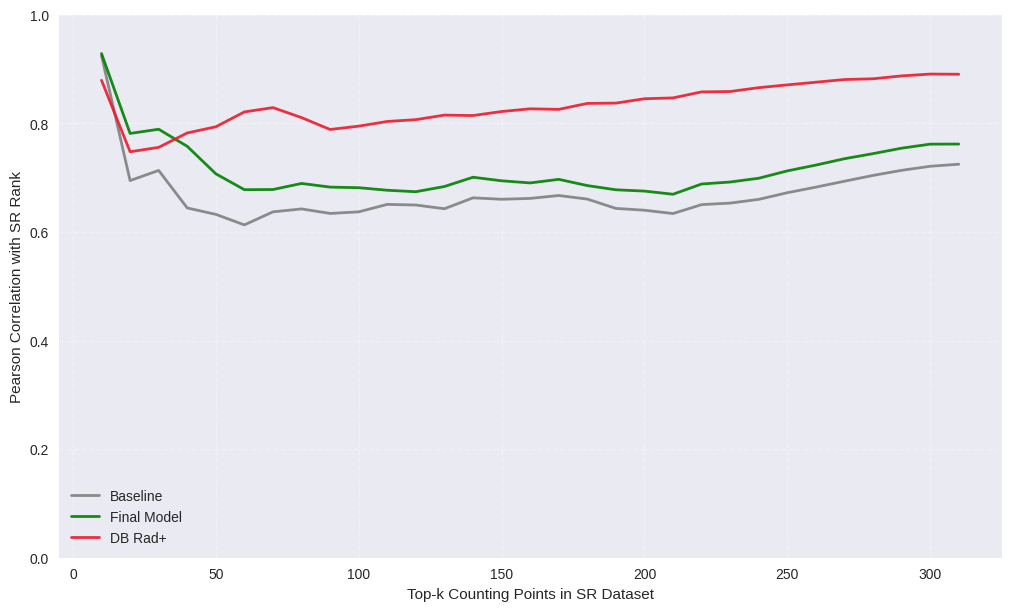

In [64]:
from scipy.stats import pearsonr

list_sim = []
list_base = []
list_base_pois = []
list_base_nrd = []
list_base_dist = []
list_sr = []

for i in range(10,len(counts_comp_df) + 5, 10):
    counts_comp_df_red = counts_comp_df[counts_comp_df["rank_sr"] < i]
    counts_comp_df_red["rank_base"] = counts_comp_df_red["count_base"].rank(ascending=False)
    counts_comp_df_red["rank_base_pois"] = counts_comp_df_red["count_base_pois"].rank(ascending=False)
    counts_comp_df_red["rank_base_nrd"] = counts_comp_df_red["count_base_nrd"].rank(ascending=False)
    counts_comp_df_red["rank_base_dist"] = counts_comp_df_red["count_base_dist"].rank(ascending=False)
    counts_comp_df_red["rank_sim"] = counts_comp_df_red["count_sim"].rank(ascending=False)
    counts_comp_df_red["rank_sr"] = counts_comp_df_red["count_sr"].rank(ascending=False)
    res_sim = pearsonr(counts_comp_df_red["count_sr"], counts_comp_df_red["count_sim"])
    res_base = pearsonr(counts_comp_df_red["count_sr"], counts_comp_df_red["count_base_pois"])
    res_sr = pearsonr(counts_comp_df_red["count_db"], counts_comp_df_red["count_sr"])
    list_base.append(res_base.statistic)
    list_base_pois.append(res_base_pois.statistic)
    list_base_nrd.append(res_base_nrd.statistic)
    list_base_dist.append(res_base_dist.statistic)
    list_sim.append(res_sim.statistic)
    list_sr.append(res_sr.statistic)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

x=range(10,len(counts_comp_df) + 5, 10)
#plt.title("Pearson Correlation with Top-K Counting Points of SR Dataset")
plt.xlabel("Top-k Counting Points in SR Dataset")
plt.ylabel("Pearson Correlation with SR Rank")
plt.ylim(0, 1)

plt.style.use('seaborn-v0_8')
plt.grid(True, linestyle='--', alpha=0.3)

plt.plot(x, list_base, label="Baseline", linewidth =2, alpha=0.9, color="gray")
plt.plot(x, list_sim, label="Final Model",linewidth =2, alpha=0.9, color="green")
plt.plot(x, list_sr, label ="DB Rad+",linewidth =2,alpha=0.9, color="#EC1B2D")
plt.legend()
plt.savefig("figures/sr_pearson_corr")

import tikzplotlib

tikzplotlib.save("figures/sr_pearson_corr.tex")

### Top-K Overlap

<Figure size 1000x600 with 0 Axes>

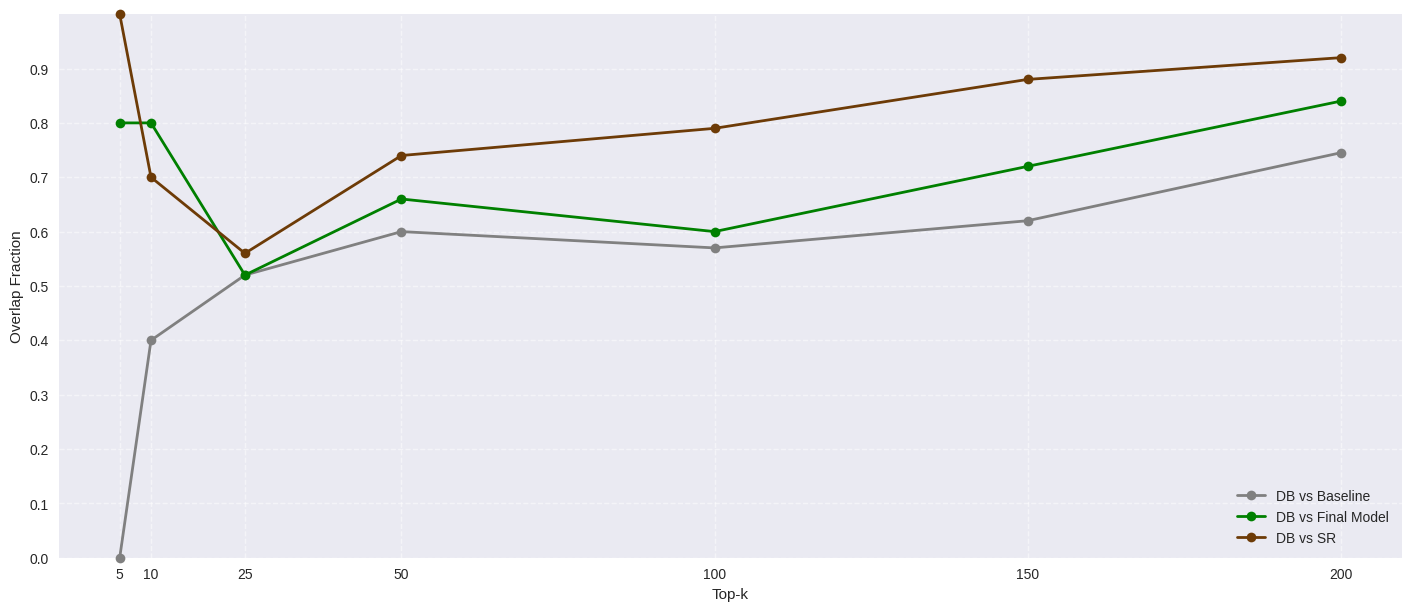

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ks = [5, 10, 25, 50, 100, 150, 200]
plt.figure(figsize=(10, 6))

comparisons = {
    "rank_base": "DB vs Baseline",
    "rank_sim": "DB vs Final Model",
    "rank_sr": "DB vs SR",
}

results = {label: [] for label in comparisons.values()}

for k in ks:
    top_db = set(counts_comp_df.nsmallest(k, "rank_db").index)

    for col, label in comparisons.items():
        top_other = set(counts_comp_df.nsmallest(k, col).index)
        overlap = len(top_db & top_other) / k
        results[label].append(overlap)


colors = ["grey", "green","#6D3B07"]

plt.figure(figsize=(14, 6))
i = 0


for label, overlaps in results.items():
    plt.plot(
        ks,
        overlaps,
        marker="o",
        linewidth=2,
        label=label,clip_on=False, color = colors[i]
    )

    i += 1
plt.yticks(np.arange(0,1, 0.1))
plt.xlabel("Top-k")
plt.ylabel("Overlap Fraction")
#plt.title("Top-k Overlap with DB Rad+ Dataset")
plt.xticks(ks)
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.savefig("figures/db_topk_overlap")

import tikzplotlib

tikzplotlib.save("figures/db_topk_overlap.tex")

<Figure size 1000x600 with 0 Axes>

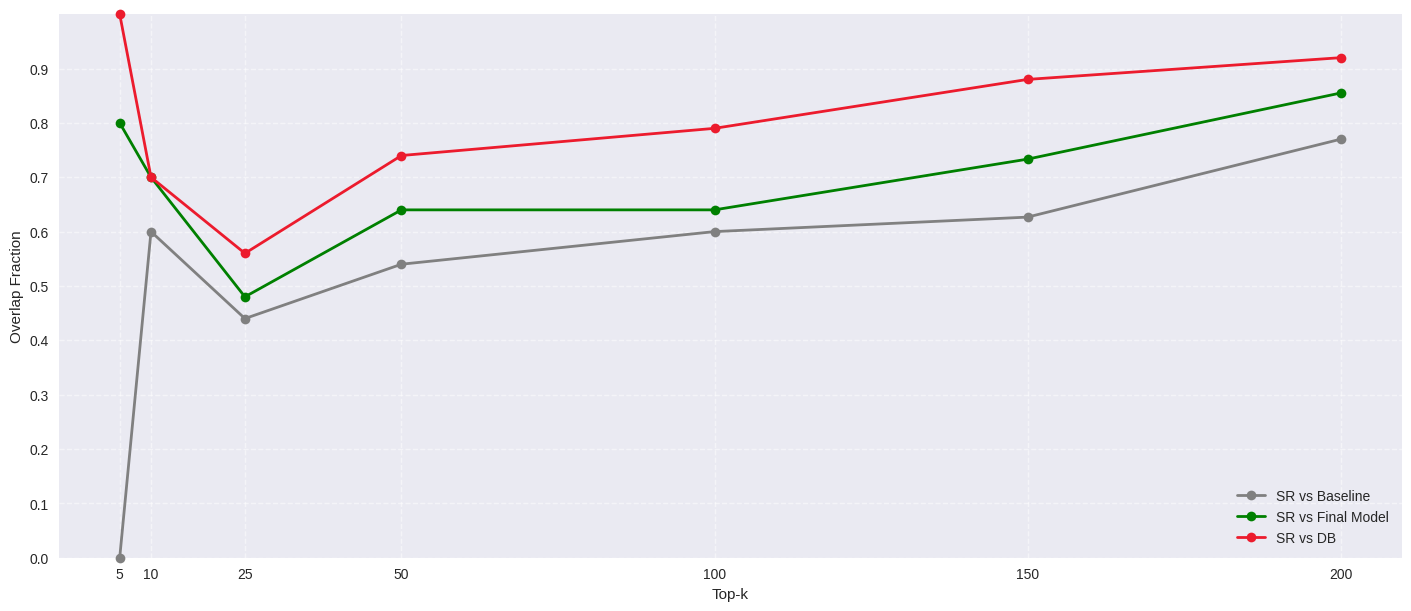

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

ks = [5, 10, 25, 50, 100, 150, 200]
plt.figure(figsize=(10, 6))

comparisons = {
    "rank_base": "SR vs Baseline",
    "rank_sim": "SR vs Final Model",
    "rank_db": "SR vs DB",
}

results = {label: [] for label in comparisons.values()}

for k in ks:
    top_db = set(counts_comp_df.nsmallest(k, "rank_sr").index)

    for col, label in comparisons.items():
        top_other = set(counts_comp_df.nsmallest(k, col).index)
        overlap = len(top_db & top_other) / k
        results[label].append(overlap)


colors = ["grey", "green","#EC1B2D"]

plt.figure(figsize=(14, 6))
i = 0


for label, overlaps in results.items():
    plt.plot(
        ks,
        overlaps,
        marker="o",
        linewidth=2,
        label=label,clip_on=False, color = colors[i]
    )

    i += 1

plt.xlabel("Top-k")
plt.ylabel("Overlap Fraction")
#plt.title("Top-k Overlap with Stadtradeln Dataset")
plt.yticks(np.arange(0,1, 0.1))
plt.xticks(ks)
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.savefig("figures/sr_topk_overlap")

import tikzplotlib

tikzplotlib.save("figures/sr_topk_overlap.tex")

### Counting Stations

In [9]:
import pandas as pd
import geopandas as gpd
query = "SELECT * FROM counting_stations_lines_hamburg"

counts_stations_gdf = gpd.GeoDataFrame.from_postgis(query,engine, geom_col="geometry")
counts_stations_gdf

,id,geometry,count_stations,num_points,count_db,count_sr,count_base,count_sim,count_base_pois,count_base_dist,count_base_non_random_des
0,1,"MULTILINESTRING ((9.96639 53.54083, 9.96662 53...",1268452,3,11264,688,8917,1691,3060,825,6322
1,2,"MULTILINESTRING ((9.93399 53.55036, 9.93402 53...",2578092,3,9608,2048,2186,2150,2366,972,4436
2,6,"MULTILINESTRING ((9.98975 53.55962, 9.99019 53...",2409702,3,16264,1832,633,1767,747,844,2036
3,7,"MULTILINESTRING ((9.99572 53.55938, 9.99604 53...",1512093,1,23364,2452,416,1064,832,550,1526
4,21,"MULTILINESTRING ((9.99797 53.55786, 9.9978 53....",2072322,2,41156,4704,8326,4792,6501,2682,13206
5,8,"MULTILINESTRING ((10.01994 53.56622, 10.01995 ...",449786,3,2340,316,59,182,78,77,168
6,9,"MULTILINESTRING ((9.99897 53.58, 9.99923 53.57...",3538866,3,32832,3912,1285,3166,2117,1479,4203
7,10,"MULTILINESTRING ((9.99957 53.58057, 9.99944 53...",1903830,3,17924,2216,245,517,475,228,755
8,11,"MULTILINESTRING ((9.97072 53.58164, 9.971 53.5...",1666940,3,5764,596,164,698,214,254,744
9,12,"MULTILINESTRING ((9.9728 53.58151, 9.97237 53....",3071310,3,10076,1936,2649,2145,2159,1213,4241


In [10]:
counts_stations_gdf["rank_real"] = counts_stations_gdf["count_stations"].rank(ascending=False)
counts_stations_gdf["rank_db"] = counts_stations_gdf["count_db"].rank(ascending=False)
counts_stations_gdf["rank_base"] = counts_stations_gdf["count_base"].rank(ascending=False)
counts_stations_gdf["rank_sim"] = counts_stations_gdf["count_sim"].rank(ascending=False)
counts_stations_gdf["rank_sr"] = counts_stations_gdf["count_sr"].rank(ascending=False)
counts_stations_gdf["rank_base_pois"] = counts_stations_gdf["count_base_pois"].rank(ascending=False)
counts_stations_gdf["rank_base_dist"] = counts_stations_gdf["count_base_dist"].rank(ascending=False)
counts_stations_gdf["rank_base_non_random_des"] = counts_stations_gdf["count_base_non_random_des"].rank(ascending=False)

In [11]:
counts_stations_gdf["count_aadt"] =  counts_stations_gdf["count_stations"] / 365
counts_stations_gdf[["count_stations","count_db","count_sr","count_base","count_base_pois","count_base_non_random_des","count_base_dist","count_sim"]].corr()

,count_stations,count_db,count_sr,count_base,count_base_pois,count_base_non_random_des,count_base_dist,count_sim
count_stations,1.000000,0.602445,0.684139,0.075840,0.304885,0.308158,0.509595,0.554769
count_db,0.602445,1.000000,0.929065,0.373361,0.594733,0.601763,0.741025,0.750414
count_sr,0.684139,0.929065,1.000000,0.281721,0.595872,0.592661,0.759684,0.780722
count_base,0.075840,0.373361,0.281721,1.000000,0.871502,0.881645,0.697245,0.676437
count_base_pois,0.304885,0.594733,0.595872,0.871502,1.000000,0.991858,0.917459,0.901168
count_base_non_random_des,0.308158,0.601763,0.592661,0.881645,0.991858,1.000000,0.925300,0.909685
count_base_dist,0.509595,0.741025,0.759684,0.697245,0.917459,0.925300,1.000000,0.992567
count_sim,0.554769,0.750414,0.780722,0.676437,0.901168,0.909685,0.992567,1.000000


P-values
rank_base                   0.460149
rank_base_pois              0.105934
rank_base_non_random_des    0.076999
rank_base_dist              0.010975
rank_sim                    0.003957
rank_sr                     0.000180
rank_db                     0.000136
Name: rank_real, dtype: float64


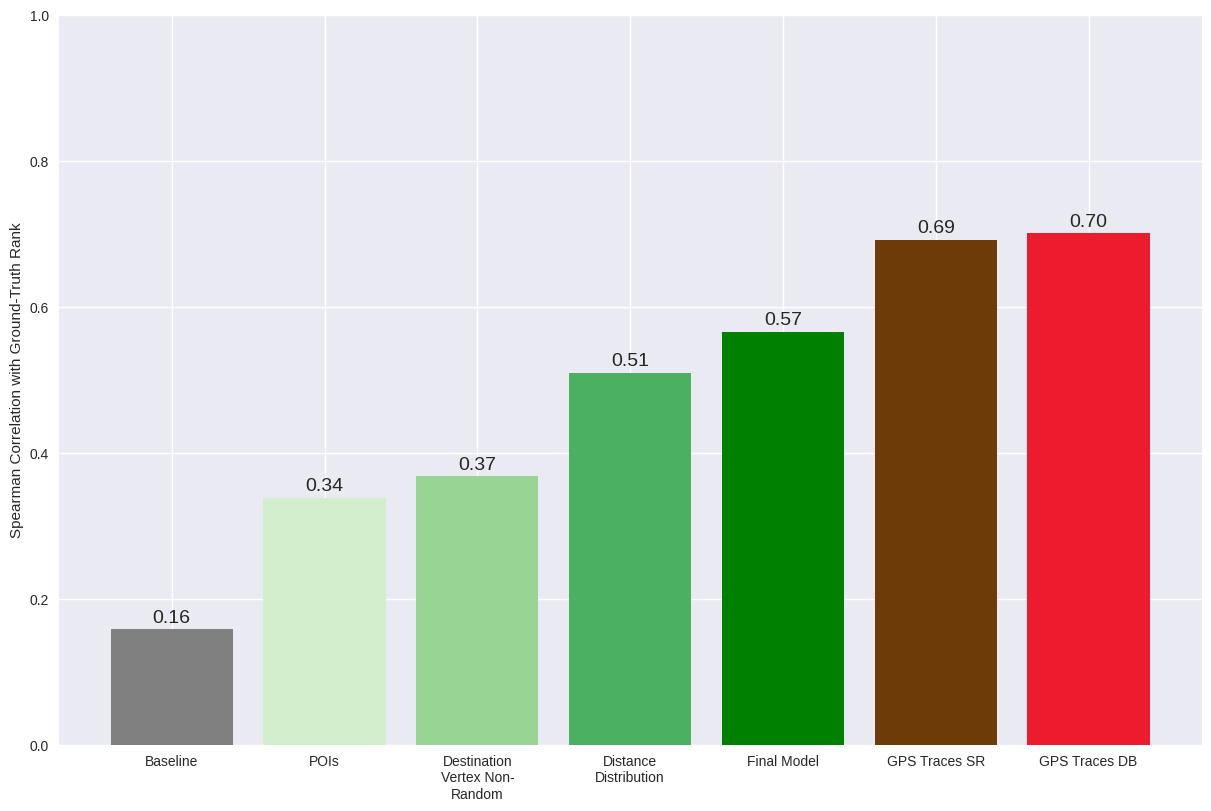

In [15]:
import seaborn as sns
import textwrap
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import numpy as np

plt.figure(figsize=(12, 8))

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.constrained_layout.use'] = True


rank_df = counts_stations_gdf[["rank_real", "rank_base", "rank_base_pois","rank_base_non_random_des","rank_base_dist","rank_sim","rank_sr","rank_db"]]

corrs = (
    rank_df
    .corr()["rank_real"]
    .drop("rank_real")
)


corr_matrix, p_matrix = spearmanr(rank_df)


pval_df = pd.DataFrame(p_matrix,
                       index=rank_df.columns,
                       columns=rank_df.columns)
print("P-values")
print(pval_df["rank_real"]
    .drop("rank_real"))

labels = ["Baseline", "POIs", "Destination Vertex Non-Random","Distance Distribution","Final Model", "GPS Traces SR","GPS Traces DB",]
wrapped_labels = [textwrap.fill(label, 14) for label in labels]

middle_colors = plt.cm.Greens(np.linspace(0.2, 0.6, 3))

colors = (
    ["gray"] +                    
    list(middle_colors) +         
    ["green", "#6D3B07", "#EC1B2D"]    
)
plt.bar(
    x=wrapped_labels,
    height=corrs.values, color=colors)

for i, v in enumerate(corrs.values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=14)

plt.ylim(0, 1)
# plt.ylabel("Spearman Correlation with Ground-Truth Rank", fontsize = 8)
# # plt.xlabel("Method")
# plt.xticks(rotation=45, ha="right", fontsize=6)
# plt.savefig("figures/hamburg_spearman")

plt.ylabel("Spearman Correlation with Ground-Truth Rank")
# # plt.xlabel("Method")
plt.savefig("figures/hamburg_spearman")
# import tikzplotlib

# # plt.tight_layout()

# tikzplotlib.save("figures/hamburg_spearman.tex")

rank_base                   0.446079
rank_base_pois              0.131272
rank_base_non_random_des    0.107397
rank_base_dist              0.017257
rank_sim                    0.010599
rank_sr                     0.001371
rank_db                     0.000966
Name: rank_real, dtype: float64


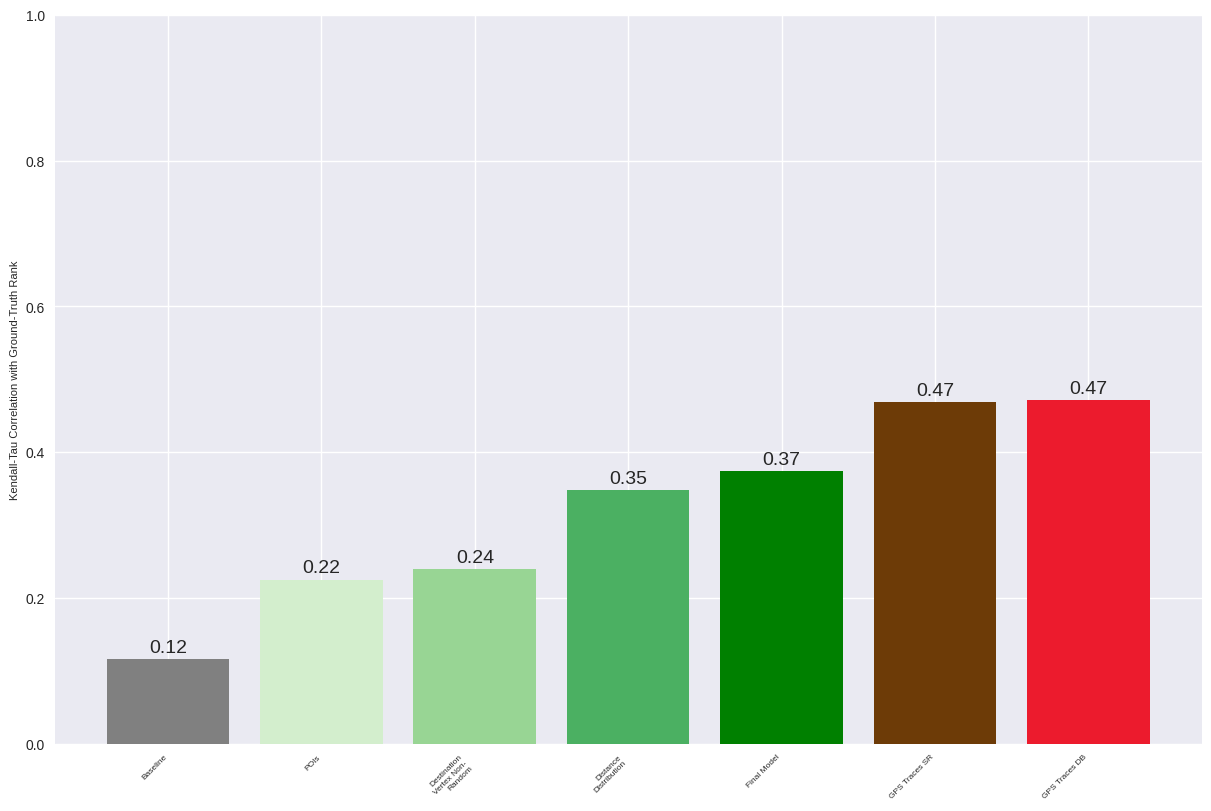

In [74]:
import seaborn as sns
import textwrap


plt.figure(figsize=(12, 8))

plt.style.use('seaborn-v0_8')

corrs = (
    counts_stations_gdf[["rank_real", "rank_base", "rank_base_pois","rank_base_non_random_des","rank_base_dist","rank_sim","rank_sr","rank_db"]]
    .corr(method="kendall")["rank_real"]
    .drop("rank_real")
)

rank_df = counts_stations_gdf[["rank_real", "rank_base", "rank_base_pois","rank_base_non_random_des","rank_base_dist","rank_sim","rank_sr","rank_db"]]


cols = rank_df.columns

corr_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)
p_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for c1 in cols:
    for c2 in cols:
        tau, pval = kendalltau(rank_df[c1], rank_df[c2])

        corr_matrix.loc[c1, c2] = tau
        p_matrix.loc[c1, c2] = pval

pval_df = pd.DataFrame(p_matrix, index=cols,columns=cols)



print(pval_df["rank_real"]
    .drop("rank_real"))


labels = ["Baseline", "POIs", "Destination Vertex Non-Random","Distance Distribution","Final Model", "GPS Traces SR","GPS Traces DB",]
wrapped_labels = [textwrap.fill(label, 14) for label in labels]

middle_colors = plt.cm.Greens(np.linspace(0.2, 0.6, 3))

colors = (
    ["gray"] +                    
    list(middle_colors) +         
    ["green", "#6D3B07", "#EC1B2D"]    
)
plt.bar(
    x=wrapped_labels,
    height=corrs.values, color=colors)


for i, v in enumerate(corrs.values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=14)

plt.ylim(0, 1)
plt.ylabel("Kendall-Tau Correlation with Ground-Truth Rank", fontsize = 8)
# plt.xlabel("Method")
plt.xticks(rotation=45, ha="right", fontsize=6)

plt.savefig("figures/hamburg_kendalltau")

import tikzplotlib

tikzplotlib.save("figures/hamburg_kendalltau.tex")

p-values
count_base                   0.724679
count_base_pois              0.147437
count_base_non_random_des    0.142922
count_base_dist              0.010970
count_sim                    0.004899
count_sr                     0.000227
count_db                     0.001837
Name: count_stations, dtype: float64


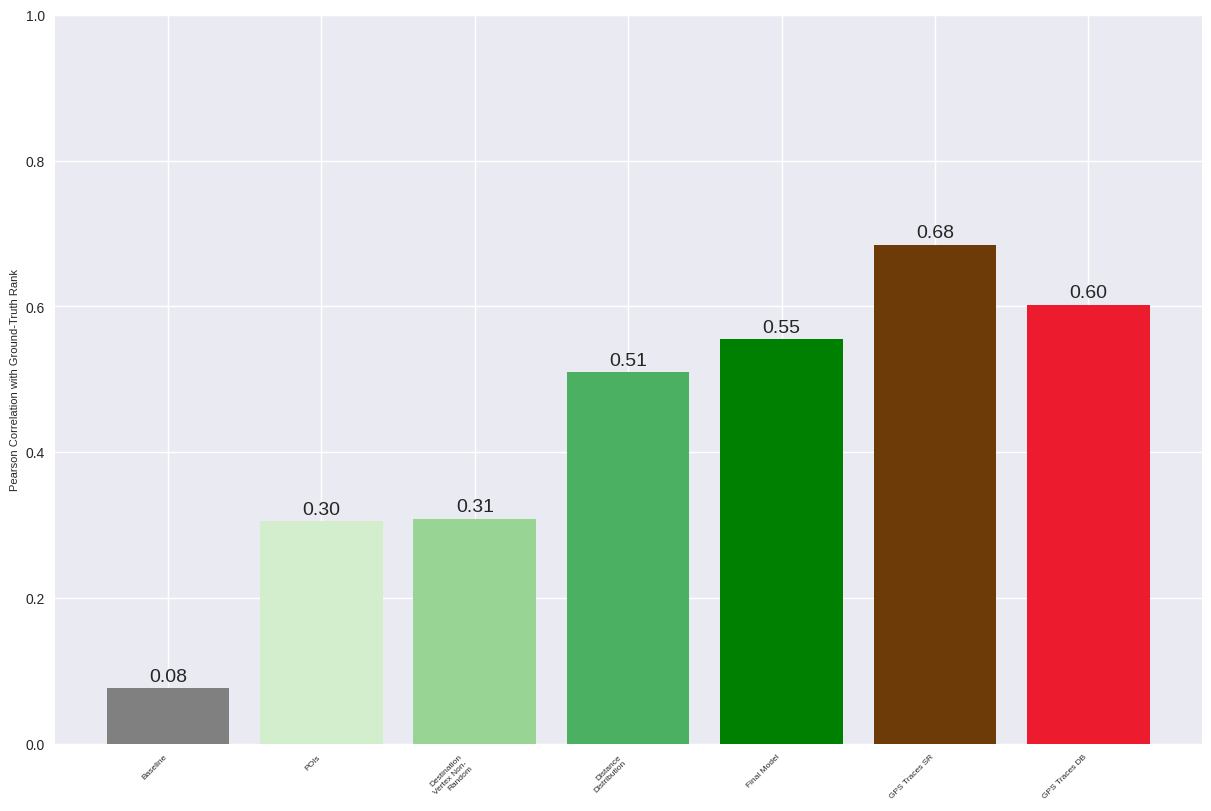

In [77]:
import seaborn as sns
import textwrap

fig, ax = plt.subplots(figsize=(12, 8))

plt.style.use('seaborn-v0_8')

corrs = (
    counts_stations_gdf[["count_stations", "count_base", "count_base_pois","count_base_non_random_des","count_base_dist","count_sim","count_sr","count_db"]]
    .corr()["count_stations"]
    .drop("count_stations")
)

count_df = counts_stations_gdf[["count_stations", "count_base", "count_base_pois","count_base_non_random_des","count_base_dist","count_sim","count_sr","count_db"]]


cols = count_df.columns

corr_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)
p_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for c1 in cols:
    for c2 in cols:
        tau, pval = pearsonr(count_df[c1], count_df[c2])

        corr_matrix.loc[c1, c2] = tau
        p_matrix.loc[c1, c2] = pval

pval_df = pd.DataFrame(p_matrix, index=cols,columns=cols)


print("p-values")
print(pval_df["count_stations"]
    .drop("count_stations"))


labels = ["Baseline", "POIs", "Destination Vertex Non-Random","Distance Distribution","Final Model", "GPS Traces SR","GPS Traces DB"]
wrapped_labels = [textwrap.fill(label, 14) for label in labels]

middle_colors = plt.cm.Greens(np.linspace(0.2, 0.6, 3))

colors = (
    ["gray"] +                    
    list(middle_colors) +         
    ["green", "#6D3B07", "#EC1B2D"]    
)
plt.bar(
    x=wrapped_labels,
    height=corrs.values, color=colors)


for i, v in enumerate(corrs.values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=14)

plt.ylim(0, 1)
plt.ylabel("Pearson Correlation with Ground-Truth Rank", fontsize = 8)
# plt.xlabel("Method")
plt.xticks(rotation=45, ha="right", fontsize=6)

plt.savefig("figures/hamburg_pearson")

import tikzplotlib

tikzplotlib.save("figures/hamburg_pearson.tex")

In [73]:
## TODO: Add p-values